# NVIDIA GTC 2027 — Matched NumPy-CPU vs CUDA-GPU Benchmark

## Fair acceleration test for exact Dangling Centrality on real BioGPT attention graphs

This notebook closes the main methodological gap in the earlier NVIDIA GTC benchmark. It compares the **same batched Floyd–Warshall formulation** on:

1. **Original CPU reference:** NetworkX implementation used in the biomedical attention-graph study.
2. **Matched optimized CPU:** NumPy implementation using the same batched adjacency-matrix algorithm as the GPU implementation.
3. **NVIDIA GPU:** CUDA/CuPy implementation using the same batched algorithm.

The **primary accelerated-computing endpoint** is therefore:

\[
\text{Matched speedup}=\frac{T_{\mathrm{NumPy\ CPU}}}{T_{\mathrm{CUDA/CuPy\ GPU}}}.
\]

The NetworkX-to-GPU result is retained only as a **secondary legacy-baseline comparison**.

### Claim gate
Do not use the earlier 9.20× NetworkX/GPU result as the final GTC headline until this matched-algorithm benchmark is complete. A defensible acceleration claim requires:

- numerical agreement between NetworkX, NumPy and CUDA/CuPy;
- the 95% bootstrap CI for the **matched NumPy/GPU median speedup** to remain above 1×;
- results on the full set of 200 real MedMCQA/BioGPT attention graphs;
- CUDA transfer/allocation overhead to remain inside the timed GPU function.

Run this notebook on the **same NVIDIA GPU type** used for the earlier benchmark if you want direct comparability. If the GPU changes, report the new hardware explicitly and do not merge timing claims across hardware.


## 1. Install packages


In [1]:
!pip -q install "transformers>=4.57,<5" "datasets>=4.0,<5" accelerate sentencepiece sacremoses networkx scipy pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 132.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.27.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 2. Imports, reproducibility, and hardware check


In [2]:
import gc
import json
import math
import os
import platform
import random
import shutil
import subprocess
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from scipy.stats import spearmanr, wilcoxon
from transformers import AutoModelForCausalLM, AutoTokenizer

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not torch.cuda.is_available():
    raise RuntimeError(
        "No NVIDIA CUDA GPU detected. In Colab choose Runtime > Change runtime type > GPU."
    )

cuda_runtime = torch.version.cuda or ""
cuda_major = int(cuda_runtime.split(".")[0]) if cuda_runtime else 12

if __import__('importlib').util.find_spec("cupy") is None:
    cupy_pkg = "cupy-cuda13x" if cuda_major >= 13 else "cupy-cuda12x"
    print("Installing", cupy_pkg)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", cupy_pkg])

import cupy as cp


def cpu_model_name():
    try:
        text = subprocess.check_output(["bash", "-lc", "lscpu | grep 'Model name' | head -1"], text=True).strip()
        return text.split(':', 1)[1].strip() if ':' in text else text
    except Exception:
        return platform.processor() or "unknown"

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("NetworkX:", nx.__version__)
print("NumPy:", np.__version__)
print("CuPy:", cp.__version__)
print("CUDA runtime:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
print("CPU:", cpu_model_name())
print("Logical CPU cores:", os.cpu_count())


Python: 3.13.15
PyTorch: 2.11.0+cu130
NetworkX: 3.6.1
NumPy: 2.1.3
CuPy: 14.0.1
CUDA runtime: 13.0
GPU: NVIDIA A100-SXM4-40GB
GPU memory (GB): 42.41
CPU: Intel(R) Xeon(R) CPU @ 2.20GHz
Logical CPU cores: 12


## 3. Configuration


In [3]:
MODEL_NAME = "microsoft/biogpt"
DATASET_NAME = "openlifescienceai/medmcqa"
DATASET_SPLIT = "validation"

MAX_LENGTH = 256
TOP_K_EDGES_PER_NODE = 5
EPS = 1e-12

# Final GTC matched-algorithm experiment.
MATCHED_N_QUESTIONS = 200
MATCHED_REPEATS = 5
BOOTSTRAP_DRAWS = 10000
CHECKPOINT_EVERY = 10
AGREEMENT_ATOL = 1e-5

OUTPUT_DIR = Path("/content/gtc_2027_matched_numpy_cuda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_CSV = OUTPUT_DIR / "matched_200_checkpoint.csv"
FAILURES_CSV = OUTPUT_DIR / "matched_200_failures.csv"

print("Questions:", MATCHED_N_QUESTIONS)
print("Timing repeats per backend:", MATCHED_REPEATS)
print("Bootstrap draws:", BOOTSTRAP_DRAWS)
print("Output directory:", OUTPUT_DIR)


Questions: 200
Timing repeats per backend: 5
Bootstrap draws: 10000
Output directory: /content/gtc_2027_matched_numpy_cuda


## 4. Load BioGPT


In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True,
)
model.config.output_attentions = True
model.config.use_cache = False
model.config.return_dict = True
model.to(DEVICE)
model.eval()

print("Model:", model.__class__.__name__)
print("Layers:", model.config.num_hidden_layers)
print("Heads:", model.config.num_attention_heads)
print("Hidden size:", model.config.hidden_size)


config.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

Model: BioGptForCausalLM
Layers: 24
Heads: 16
Hidden size: 1024


## 5. Load and normalize MedMCQA


In [5]:
dataset = load_dataset(
    DATASET_NAME,
    split=DATASET_SPLIT,
    trust_remote_code=True
)

print("Samples:", len(dataset))
print("Columns:", dataset.column_names)
print(dataset[0])


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openlifescienceai/medmcqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openlifescienceai/medmcqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/85.9M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/936k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.48M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/182822 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6150 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4183 [00:00<?, ? examples/s]

Samples: 4183
Columns: ['id', 'question', 'opa', 'opb', 'opc', 'opd', 'cop', 'choice_type', 'exp', 'subject_name', 'topic_name']
{'id': '45258d3d-b974-44dd-a161-c3fccbdadd88', 'question': 'Which of the following is not true for myelinated nerve fibers:', 'opa': 'Impulse through myelinated fibers is slower than non-myelinated fibers', 'opb': 'Membrane currents are generated at nodes of Ranvier', 'opc': 'Saltatory conduction of impulses is seen', 'opd': 'Local anesthesia is effective only when the nerve is not covered by myelin sheath', 'cop': 0, 'choice_type': 'multi', 'exp': None, 'subject_name': 'Physiology', 'topic_name': None}


In [6]:
def normalize_sample(sample):
    """Return question, ordered option dict, and zero-based correct index.

    Handles common MedMCQA schemas and the options-dictionary schema used
    in earlier notebooks.
    """
    question = str(sample["question"]).strip()

    # Common native MedMCQA schema: opa, opb, opc, opd, cop.
    if all(key in sample for key in ["opa", "opb", "opc", "opd"]):
        options = {
            "A": str(sample["opa"]).strip(),
            "B": str(sample["opb"]).strip(),
            "C": str(sample["opc"]).strip(),
            "D": str(sample["opd"]).strip(),
        }
        correct_idx = int(sample["cop"]) if sample.get("cop") is not None else None
        return question, options, correct_idx

    # Generic options schema.
    options_raw = sample.get("options")
    options = {}

    if isinstance(options_raw, dict):
        if "key" in options_raw and "value" in options_raw:
            options = {
                str(k): str(v).strip()
                for k, v in zip(options_raw["key"], options_raw["value"])
            }
        else:
            options = {str(k): str(v).strip() for k, v in options_raw.items()}

    elif isinstance(options_raw, list):
        for i, item in enumerate(options_raw):
            key = chr(65 + i)
            if isinstance(item, dict):
                options[str(item.get("key", key))] = str(
                    item.get("value", item.get("text", ""))
                ).strip()
            else:
                options[key] = str(item).strip()

    if not options:
        raise ValueError("Could not recover answer options from this sample.")

    answer_idx = sample.get("answer_idx", sample.get("answer"))
    correct_idx = None

    if answer_idx is not None:
        if isinstance(answer_idx, str):
            stripped = answer_idx.strip()
            if stripped in options:
                correct_idx = list(options.keys()).index(stripped)
            else:
                try:
                    correct_idx = int(stripped)
                except Exception:
                    correct_idx = None
        else:
            correct_idx = int(answer_idx)

    return question, options, correct_idx


q0, opts0, y0 = normalize_sample(dataset[0])
print(q0)
print(opts0)
print("Correct index:", y0)


Which of the following is not true for myelinated nerve fibers:
{'A': 'Impulse through myelinated fibers is slower than non-myelinated fibers', 'B': 'Membrane currents are generated at nodes of Ranvier', 'C': 'Saltatory conduction of impulses is seen', 'D': 'Local anesthesia is effective only when the nerve is not covered by myelin sheath'}
Correct index: 0


## 6. Prompt construction


In [7]:
def build_prompt(question, options):
    lines = [
        "Clinical question:",
        str(question).strip(),
        "",
        "Possible answers:",
    ]
    lines.extend(f"{k}. {v}" for k, v in options.items())
    lines.extend(["", "Answer:"])
    return "\n".join(lines)


def continuation_logprob(prompt_ids_1d, continuation_text):
    """Length-normalized causal log-probability of one candidate continuation."""
    continuation_ids = tokenizer(
        " " + str(continuation_text).strip(),
        add_special_tokens=False,
        return_tensors="pt"
    )["input_ids"][0]

    full_ids = torch.cat([
        prompt_ids_1d.detach().cpu(),
        continuation_ids.detach().cpu()
    ])

    labels = full_ids.clone()
    prompt_len = len(prompt_ids_1d)
    labels[:prompt_len] = -100

    input_ids = full_ids.unsqueeze(0).to(DEVICE)
    labels = labels.unsqueeze(0).to(DEVICE)

    with torch.inference_mode():
        out = model(
            input_ids=input_ids,
            labels=labels,
            use_cache=False,
            return_dict=True
        )

    # Hugging Face causal-LM loss is mean negative log-likelihood
    # over the unmasked continuation tokens.
    return -float(out.loss.detach().cpu())


def score_options(prompt_ids_1d, options):
    keys = list(options.keys())
    values = [options[k] for k in keys]

    scores = np.array(
        [continuation_logprob(prompt_ids_1d, text) for text in values],
        dtype=float
    )

    # Convert normalized log scores to a 4-way probability distribution.
    shifted = scores - scores.max()
    probs = np.exp(shifted)
    probs = probs / probs.sum()

    pred_idx = int(np.argmax(probs))

    return {
        "keys": keys,
        "scores": scores,
        "probs": probs,
        "pred_idx": pred_idx,
        "pred_key": keys[pred_idx],
        "pred_prob": float(probs[pred_idx]),
    }


## 7. Attention extraction and word-level aggregation


In [8]:
SPECIAL_TOKENS = set(tokenizer.all_special_tokens)

def merge_biogpt_subwords(tokens):
    merged_tokens = []
    groups = []
    current_pieces = []
    current_indices = []

    def close_current():
        nonlocal current_pieces, current_indices
        if current_indices:
            text = "".join(current_pieces).strip()
            if not text:
                text = "".join(str(tokens[i]) for i in current_indices)
            merged_tokens.append(text)
            groups.append(current_indices.copy())
        current_pieces = []
        current_indices = []

    for index, raw_token in enumerate(tokens):
        token = str(raw_token)

        if token in SPECIAL_TOKENS:
            close_current()
            merged_tokens.append(token)
            groups.append([index])

        elif token.endswith("</w>"):
            current_pieces.append(token[:-4])
            current_indices.append(index)
            close_current()

        elif token.startswith("Ġ") or token.startswith("▁"):
            close_current()
            current_pieces = [token[1:]]
            current_indices = [index]

        elif token.startswith("##"):
            current_pieces.append(token[2:])
            current_indices.append(index)

        else:
            current_pieces.append(token)
            current_indices.append(index)

    close_current()

    flattened = [i for group in groups for i in group]
    if sorted(flattened) != list(range(len(tokens))):
        raise RuntimeError("Subword merging lost or duplicated indices.")

    return merged_tokens, groups


def aggregate_attention_to_words(subword_attention, groups):
    n = len(groups)
    word_attention = np.zeros((n, n), dtype=np.float64)

    for source_word, source_indices in enumerate(groups):
        for target_word, target_indices in enumerate(groups):
            block = subword_attention[np.ix_(source_indices, target_indices)]
            word_attention[source_word, target_word] = float(block.mean())

    return word_attention


def extract_prompt_attention(prompt):
    encoded = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=True,
    )

    input_ids_cpu = encoded["input_ids"][0].clone()
    model_inputs = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    with torch.inference_mode():
        outputs = model(
            **model_inputs,
            output_attentions=True,
            use_cache=False,
            return_dict=True,
        )

    if outputs.attentions is None:
        raise RuntimeError("BioGPT returned no attention tensors.")

    # Same aggregation used in the earlier attention-graph notebook:
    # mean over heads inside each layer, then mean over layers.
    layer_means = [
        layer_attention[0].float().mean(dim=0).cpu()
        for layer_attention in outputs.attentions
    ]

    mean_subword_attention = (
        torch.stack(layer_means, dim=0)
        .mean(dim=0)
        .numpy()
        .astype(np.float64)
    )

    subword_tokens = tokenizer.convert_ids_to_tokens(input_ids_cpu.tolist())
    merged_tokens, groups = merge_biogpt_subwords(subword_tokens)
    merged_attention = aggregate_attention_to_words(
        mean_subword_attention,
        groups
    )

    return {
        "prompt_ids": input_ids_cpu,
        "subword_tokens": subword_tokens,
        "merged_tokens": merged_tokens,
        "groups": groups,
        "subword_attention": mean_subword_attention,
        "merged_attention": merged_attention,
    }


## 8. Sparse attention graph and original NetworkX Dangling Centrality


In [9]:
def build_sparse_attention_graph(tokens, attention_matrix, top_k=5):
    graph = nx.DiGraph()

    retained = []
    for node_id, token in enumerate(tokens):
        text = str(token).strip()

        if token in SPECIAL_TOKENS:
            continue
        if not text or not any(ch.isalnum() for ch in text):
            continue

        retained.append(node_id)
        graph.add_node(
            int(node_id),
            token=str(token),
            position=int(node_id)
        )

    for source_id in retained:
        candidates = []

        for target_id in retained:
            if source_id == target_id:
                continue

            weight = float(attention_matrix[source_id, target_id])

            if np.isfinite(weight) and weight > 0:
                candidates.append((target_id, weight))

        candidates.sort(key=lambda item: (-item[1], item[0]))

        for target_id, weight in candidates[:top_k]:
            graph.add_edge(
                int(source_id),
                int(target_id),
                weight=weight,
                attention=weight
            )

    return graph


def communication_score(undirected_graph):
    """Published reciprocal shortest-path communication sum over unordered pairs."""
    score = 0.0

    for source, lengths in nx.all_pairs_shortest_path_length(undirected_graph):
        for target, distance in lengths.items():
            if source < target and distance > 0:
                score += 1.0 / float(distance)

    return score


def dangling_centrality(graph):
    """Published unweighted undirected structural-projection DC."""
    U = nx.Graph()
    U.add_nodes_from(graph.nodes())
    U.add_edges_from((u, v) for u, v in graph.edges() if u != v)

    base = communication_score(U)

    dc = {}
    if base <= 0:
        return {node: 0.0 for node in U.nodes()}

    for node in U.nodes():
        perturbed = U.copy()

        incident = list(perturbed.edges(node))
        perturbed.remove_edges_from(incident)

        after = communication_score(perturbed)
        dc[node] = (base - after) / base

    return dc


def attention_entropy_and_omega(graph, dc):
    n = max(graph.number_of_nodes(), 1)

    rows = []

    for node in graph.nodes():
        outgoing = [
            float(data["weight"])
            for _, _, data in graph.out_edges(node, data=True)
            if float(data["weight"]) > 0
        ]

        k_i = len(outgoing)

        if k_i <= 1:
            H_i = 0.0
        else:
            weights = np.asarray(outgoing, dtype=float)
            p = weights / weights.sum()
            H_i = -float(np.sum(p * np.log(p + EPS))) / math.log(k_i)

        total_degree = graph.in_degree(node) + graph.out_degree(node)

        if n <= 1:
            degree_norm = 0.0
        else:
            degree_norm = total_degree / (2.0 * (n - 1))
            degree_norm = float(np.clip(degree_norm, 0.0, 1.0))

        H_star = H_i * (1.0 - degree_norm)
        omega = float(dc.get(node, 0.0)) * H_star

        rows.append({
            "node_id": int(node),
            "token": graph.nodes[node].get("token", str(node)),
            "phi_C": float(dc.get(node, 0.0)),
            "H": H_i,
            "degree_norm": degree_norm,
            "H_star": H_star,
            "Omega_MH": omega,
        })

    return pd.DataFrame(rows)


## 9. Matched NumPy and CUDA/CuPy implementations

Both functions below execute the same algorithm:

- convert the directed attention graph to the same unweighted undirected structural projection;
- create \(N+1\) graph variants: the original graph plus one node-dangling perturbation per node;
- compute all-pairs shortest paths with batched Floyd–Warshall;
- compute the reciprocal shortest-path communication score;
- calculate the exact published Dangling Centrality from the communication loss.

The NumPy and CuPy implementations differ only in the array backend. The CUDA timing includes graph-to-array conversion, CPU→GPU transfer, GPU computation, and GPU→CPU transfer of the final centrality vector.


In [10]:
def graph_to_undirected_adjacency(graph):
    nodes = list(graph.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)

    adj = np.zeros((n, n), dtype=np.bool_)
    for u, v in graph.edges():
        if u == v:
            continue
        i = node_to_idx[u]
        j = node_to_idx[v]
        adj[i, j] = True
        adj[j, i] = True

    return adj, nodes


def _numpy_communication_scores_from_adjacency_batch(adj_batch_np):
    """Batched Floyd–Warshall on CPU using NumPy; shape [B,N,N]."""
    batch_size, n, _ = adj_batch_np.shape

    dist = np.where(
        adj_batch_np,
        np.float32(1.0),
        np.float32(np.inf)
    ).astype(np.float32, copy=False)

    idx = np.arange(n)
    dist[:, idx, idx] = np.float32(0.0)

    for k in range(n):
        through_k = dist[:, :, k:k+1] + dist[:, k:k+1, :]
        np.minimum(dist, through_k, out=dist)

    ii, jj = np.triu_indices(n, k=1)
    upper = dist[:, ii, jj]

    reciprocal = np.zeros_like(upper, dtype=np.float32)
    valid = np.isfinite(upper) & (upper > 0)
    reciprocal[valid] = np.float32(1.0) / upper[valid]

    return reciprocal.sum(axis=1)


def _cupy_communication_scores_from_adjacency_batch(adj_batch_cp):
    """Same batched Floyd–Warshall algorithm on NVIDIA GPU using CuPy."""
    batch_size, n, _ = adj_batch_cp.shape

    dist = cp.where(
        adj_batch_cp,
        cp.float32(1.0),
        cp.float32(cp.inf)
    ).astype(cp.float32)

    idx = cp.arange(n)
    dist[:, idx, idx] = cp.float32(0.0)

    for k in range(n):
        through_k = dist[:, :, k:k+1] + dist[:, k:k+1, :]
        dist = cp.minimum(dist, through_k)

    ii, jj = cp.triu_indices(n, k=1)
    upper = dist[:, ii, jj]

    reciprocal = cp.where(
        cp.isfinite(upper) & (upper > 0),
        cp.float32(1.0) / upper,
        cp.float32(0.0)
    )

    return reciprocal.sum(axis=1)


def dangling_centrality_numpy_matched(graph):
    adj, nodes = graph_to_undirected_adjacency(graph)
    n = len(nodes)

    if n == 0:
        return {}

    variants = np.broadcast_to(adj, (n + 1, n, n)).copy()
    for v in range(n):
        variants[v + 1, v, :] = False
        variants[v + 1, :, v] = False

    scores = _numpy_communication_scores_from_adjacency_batch(variants)
    base = float(scores[0])

    if base <= 0:
        return {node: 0.0 for node in nodes}

    dc = (base - scores[1:]) / base
    return {node: float(dc[i]) for i, node in enumerate(nodes)}


def dangling_centrality_cuda_matched(graph):
    adj_np, nodes = graph_to_undirected_adjacency(graph)
    n = len(nodes)

    if n == 0:
        return {}

    # CPU -> GPU transfer is intentionally INSIDE the measured function.
    adj = cp.asarray(adj_np)

    variants = cp.broadcast_to(adj, (n + 1, n, n)).copy()
    for v in range(n):
        variants[v + 1, v, :] = False
        variants[v + 1, :, v] = False

    scores = _cupy_communication_scores_from_adjacency_batch(variants)
    base = scores[0]

    if float(base.get()) <= 0:
        return {node: 0.0 for node in nodes}

    dc = (base - scores[1:]) / base

    # GPU -> CPU transfer is intentionally INSIDE the measured function.
    dc_np = cp.asnumpy(dc)
    return {node: float(dc_np[i]) for i, node in enumerate(nodes)}


def compare_dc_dicts(reference_dc, test_dc, atol=AGREEMENT_ATOL):
    common = sorted(set(reference_dc) & set(test_dc))
    if not common:
        return {"n_nodes": 0, "max_abs_error": np.nan, "mean_abs_error": np.nan, "passed": False}

    errors = np.asarray([
        abs(float(reference_dc[node]) - float(test_dc[node]))
        for node in common
    ], dtype=float)

    return {
        "n_nodes": len(common),
        "max_abs_error": float(errors.max()),
        "mean_abs_error": float(errors.mean()),
        "passed": bool(np.all(errors <= atol)),
    }


## 10. Correctness gate on one real BioGPT graph


In [11]:
def attention_graph_for_question(question_index):
    sample = dataset[int(question_index)]
    question, options, correct_idx = normalize_sample(sample)
    prompt = build_prompt(question, options)

    torch.cuda.synchronize()
    t0 = time.perf_counter()
    bundle = extract_prompt_attention(prompt)
    torch.cuda.synchronize()
    inference_seconds = time.perf_counter() - t0

    t1 = time.perf_counter()
    graph = build_sparse_attention_graph(
        bundle["merged_tokens"],
        bundle["merged_attention"],
        top_k=TOP_K_EDGES_PER_NODE
    )
    graph_build_seconds = time.perf_counter() - t1

    return {
        "question_index": int(question_index),
        "question": question,
        "correct_idx": correct_idx,
        "graph": graph,
        "inference_seconds": float(inference_seconds),
        "graph_build_seconds": float(graph_build_seconds),
    }


pilot_item = attention_graph_for_question(0)
pilot_graph = pilot_item["graph"]

nx_dc = dangling_centrality(pilot_graph)
np_dc = dangling_centrality_numpy_matched(pilot_graph)
gpu_dc = dangling_centrality_cuda_matched(pilot_graph)
cp.cuda.Stream.null.synchronize()

check_np = compare_dc_dicts(nx_dc, np_dc)
check_gpu = compare_dc_dicts(nx_dc, gpu_dc)
check_matched = compare_dc_dicts(np_dc, gpu_dc)

print("Pilot nodes:", pilot_graph.number_of_nodes())
print("Pilot edges:", pilot_graph.number_of_edges())
print("NetworkX vs NumPy:", check_np)
print("NetworkX vs CUDA:", check_gpu)
print("NumPy vs CUDA:", check_matched)

assert check_np["passed"], "NumPy matched implementation does not reproduce NetworkX reference."
assert check_gpu["passed"], "CUDA implementation does not reproduce NetworkX reference."
assert check_matched["passed"], "NumPy and CUDA matched implementations disagree."


Pilot nodes: 58
Pilot edges: 275
NetworkX vs NumPy: {'n_nodes': 58, 'max_abs_error': 1.6864076778921877e-06, 'mean_abs_error': 2.607887087515769e-07, 'passed': True}
NetworkX vs CUDA: {'n_nodes': 58, 'max_abs_error': 1.3544334148685166e-07, 'mean_abs_error': 3.827551122073573e-08, 'passed': True}
NumPy vs CUDA: {'n_nodes': 58, 'max_abs_error': 1.7136335372924805e-06, 'mean_abs_error': 2.717856189300274e-07, 'passed': True}


## 11. Fair timing functions and three-backend benchmark


In [12]:
def median_runtime_seconds(fn, repeats=5, gpu=False):
    # Warm-up is excluded from timing.
    _ = fn()
    if gpu:
        cp.cuda.Stream.null.synchronize()

    times = []
    for _ in range(repeats):
        if gpu:
            cp.cuda.Stream.null.synchronize()

        t0 = time.perf_counter()
        _ = fn()

        if gpu:
            cp.cuda.Stream.null.synchronize()

        times.append(time.perf_counter() - t0)

    return float(np.median(times))


def benchmark_three_backends(graph, repeats=MATCHED_REPEATS):
    networkx_seconds = median_runtime_seconds(
        lambda: dangling_centrality(graph), repeats=repeats, gpu=False
    )
    numpy_seconds = median_runtime_seconds(
        lambda: dangling_centrality_numpy_matched(graph), repeats=repeats, gpu=False
    )
    cuda_seconds = median_runtime_seconds(
        lambda: dangling_centrality_cuda_matched(graph), repeats=repeats, gpu=True
    )

    # Correctness is checked independently of timed runs.
    ref = dangling_centrality(graph)
    np_result = dangling_centrality_numpy_matched(graph)
    cuda_result = dangling_centrality_cuda_matched(graph)
    cp.cuda.Stream.null.synchronize()

    agree_np = compare_dc_dicts(ref, np_result)
    agree_cuda = compare_dc_dicts(ref, cuda_result)
    agree_np_cuda = compare_dc_dicts(np_result, cuda_result)

    return {
        "n_nodes": int(graph.number_of_nodes()),
        "n_edges": int(graph.number_of_edges()),
        "networkx_seconds": networkx_seconds,
        "numpy_matched_seconds": numpy_seconds,
        "cuda_matched_seconds": cuda_seconds,
        "speedup_networkx_over_cuda": networkx_seconds / cuda_seconds if cuda_seconds > 0 else np.nan,
        "speedup_networkx_over_numpy": networkx_seconds / numpy_seconds if numpy_seconds > 0 else np.nan,
        "speedup_numpy_over_cuda": numpy_seconds / cuda_seconds if cuda_seconds > 0 else np.nan,
        "max_abs_error_networkx_numpy": agree_np["max_abs_error"],
        "max_abs_error_networkx_cuda": agree_cuda["max_abs_error"],
        "max_abs_error_numpy_cuda": agree_np_cuda["max_abs_error"],
        "agreement_networkx_numpy": agree_np["passed"],
        "agreement_networkx_cuda": agree_cuda["passed"],
        "agreement_numpy_cuda": agree_np_cuda["passed"],
    }


pilot_bench = benchmark_three_backends(pilot_graph)
pd.Series(pilot_bench)


,0
n_nodes,58
n_edges,275
networkx_seconds,0.1921
numpy_matched_seconds,0.017984
cuda_matched_seconds,0.005291
speedup_networkx_over_cuda,36.30475
speedup_networkx_over_numpy,10.681689
speedup_numpy_over_cuda,3.398784
max_abs_error_networkx_numpy,0.000002
max_abs_error_networkx_cuda,0.0


## 12. Run / resume the 200-question matched benchmark

This is the final real-data benchmark for the abstract. Every 10 questions a checkpoint is written. If a cell fails, the failure is recorded rather than silently dropped.


In [13]:
N = min(MATCHED_N_QUESTIONS, len(dataset))
indices = list(range(N))

if CHECKPOINT_CSV.exists():
    existing = pd.read_csv(CHECKPOINT_CSV)
    rows = existing.to_dict("records")
    completed = set(existing["question_index"].astype(int).tolist())
    print("Resuming from", len(completed), "completed questions.")
else:
    rows = []
    completed = set()

if FAILURES_CSV.exists() and FAILURES_CSV.stat().st_size > 0:
    try:
        failures_df_old = pd.read_csv(FAILURES_CSV)
        failures = failures_df_old.to_dict("records")
    except Exception:
        failures = []
else:
    failures = []

start = time.time()
new_since_save = 0

for question_index in indices:
    if question_index in completed:
        continue

    try:
        item = attention_graph_for_question(question_index)
        graph = item["graph"]
        bench = benchmark_three_backends(graph, repeats=MATCHED_REPEATS)

        row = {
            "question_index": int(question_index),
            "biogpt_cuda_inference_seconds": item["inference_seconds"],
            "graph_build_seconds": item["graph_build_seconds"],
            **bench,
        }
        rows.append(row)
        completed.add(question_index)
        new_since_save += 1

        print(
            f"{len(completed):3d}/{N} | q={question_index:3d} | "
            f"nodes={graph.number_of_nodes():3d} | "
            f"NX/GPU={bench['speedup_networkx_over_cuda']:7.2f}x | "
            f"NumPy/GPU={bench['speedup_numpy_over_cuda']:7.2f}x | "
            f"agree={bench['agreement_numpy_cuda']}"
        )

    except Exception as exc:
        failures.append({"question_index": int(question_index), "error": repr(exc)})
        print("FAILED", question_index, repr(exc))

    if new_since_save >= CHECKPOINT_EVERY:
        pd.DataFrame(rows).drop_duplicates("question_index", keep="last").sort_values("question_index").to_csv(CHECKPOINT_CSV, index=False)
        pd.DataFrame(failures).to_csv(FAILURES_CSV, index=False)
        new_since_save = 0
        print(f"Checkpoint | completed={len(completed)} | failures={len(failures)} | elapsed={(time.time()-start)/60:.1f} min")

    gc.collect()
    torch.cuda.empty_cache()
    cp.get_default_memory_pool().free_all_blocks()

matched_df = (
    pd.DataFrame(rows)
    .drop_duplicates("question_index", keep="last")
    .sort_values("question_index")
    .reset_index(drop=True)
)
failures_df = pd.DataFrame(failures)

matched_df.to_csv(CHECKPOINT_CSV, index=False)
failures_df.to_csv(FAILURES_CSV, index=False)

print("\nCompleted:", len(matched_df), "/", N)
print("Failures:", len(failures_df))
display(matched_df.head())

if len(matched_df):
    assert matched_df["agreement_networkx_numpy"].astype(bool).all()
    assert matched_df["agreement_networkx_cuda"].astype(bool).all()
    assert matched_df["agreement_numpy_cuda"].astype(bool).all()


  1/200 | q=  0 | nodes= 58 | NX/GPU=  35.83x | NumPy/GPU=   3.37x | agree=True
  2/200 | q=  1 | nodes= 77 | NX/GPU=  64.60x | NumPy/GPU=   8.20x | agree=True
  3/200 | q=  2 | nodes=105 | NX/GPU= 121.28x | NumPy/GPU=  18.81x | agree=True
  4/200 | q=  3 | nodes= 18 | NX/GPU=   3.53x | NumPy/GPU=   0.22x | agree=True
  5/200 | q=  4 | nodes= 27 | NX/GPU=   7.86x | NumPy/GPU=   0.41x | agree=True
  6/200 | q=  5 | nodes= 16 | NX/GPU=   2.86x | NumPy/GPU=   0.19x | agree=True
  7/200 | q=  6 | nodes= 63 | NX/GPU=  42.78x | NumPy/GPU=   4.45x | agree=True
  8/200 | q=  7 | nodes= 39 | NX/GPU=  16.27x | NumPy/GPU=   0.97x | agree=True
  9/200 | q=  8 | nodes= 23 | NX/GPU=   5.70x | NumPy/GPU=   0.30x | agree=True
 10/200 | q=  9 | nodes= 44 | NX/GPU=  20.99x | NumPy/GPU=   1.36x | agree=True
Checkpoint | completed=10 | failures=0 | elapsed=0.3 min
 11/200 | q= 10 | nodes= 30 | NX/GPU=   9.78x | NumPy/GPU=   0.52x | agree=True
 12/200 | q= 11 | nodes= 82 | NX/GPU=  73.97x | NumPy/GPU=   9.

,question_index,biogpt_cuda_inference_seconds,graph_build_seconds,n_nodes,n_edges,networkx_seconds,numpy_matched_seconds,cuda_matched_seconds,speedup_networkx_over_cuda,speedup_networkx_over_numpy,speedup_numpy_over_cuda,max_abs_error_networkx_numpy,max_abs_error_networkx_cuda,max_abs_error_numpy_cuda,agreement_networkx_numpy,agreement_networkx_cuda,agreement_numpy_cuda
0,0,0.079753,0.005366,58,275,0.190658,0.017923,0.005321,35.832273,10.637323,3.368542,1.686408e-06,1.354433e-07,1.713634e-06,True,True,True
1,1,0.114086,0.008284,77,370,0.415884,0.052796,0.006438,64.600360,7.877247,8.200881,1.531035e-06,2.145289e-07,1.471490e-06,True,True,True
2,2,0.186939,0.015003,105,510,0.998721,0.154873,0.008235,121.283662,6.448659,18.807580,2.666816e-06,1.194702e-07,2.741814e-06,True,True,True
3,3,0.057460,0.000636,18,75,0.009160,0.000577,0.002593,3.533146,15.883004,0.222448,4.723116e-08,4.723116e-08,0.000000e+00,True,True,True
4,4,0.034366,0.001208,27,120,0.025453,0.001334,0.003240,7.856897,19.082045,0.411743,3.979315e-07,7.517753e-08,3.948808e-07,True,True,True


## 13. Statistical robustness — primary matched NumPy/CPU vs CUDA/GPU result


In [14]:
def bootstrap_ci(values, statistic=np.median, draws=10000, seed=42, confidence=0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (np.nan, np.nan)

    rng = np.random.default_rng(seed)
    n = len(values)
    stats = np.empty(draws, dtype=float)
    for b in range(draws):
        sample = values[rng.integers(0, n, size=n)]
        stats[b] = statistic(sample)

    alpha = (1.0 - confidence) / 2.0
    return float(np.quantile(stats, alpha)), float(np.quantile(stats, 1.0 - alpha))


def geometric_mean_positive(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    return float(np.exp(np.mean(np.log(values)))) if len(values) else np.nan


analysis = matched_df.copy()
valid_mask = (
    analysis["agreement_networkx_numpy"].astype(bool)
    & analysis["agreement_networkx_cuda"].astype(bool)
    & analysis["agreement_numpy_cuda"].astype(bool)
    & (analysis["networkx_seconds"] > 0)
    & (analysis["numpy_matched_seconds"] > 0)
    & (analysis["cuda_matched_seconds"] > 0)
)
analysis = analysis.loc[valid_mask].copy()

matched_speedups = analysis["speedup_numpy_over_cuda"].to_numpy(float)
legacy_speedups = analysis["speedup_networkx_over_cuda"].to_numpy(float)
cpu_algo_speedups = analysis["speedup_networkx_over_numpy"].to_numpy(float)

matched_median = float(np.median(matched_speedups))
matched_ci = bootstrap_ci(matched_speedups, np.median, BOOTSTRAP_DRAWS, SEED)
matched_geom = geometric_mean_positive(matched_speedups)
matched_geom_ci = bootstrap_ci(matched_speedups, geometric_mean_positive, BOOTSTRAP_DRAWS, SEED + 1)
matched_q1 = float(np.quantile(matched_speedups, 0.25))
matched_q3 = float(np.quantile(matched_speedups, 0.75))

legacy_median = float(np.median(legacy_speedups))
cpu_algo_median = float(np.median(cpu_algo_speedups))

wilcox_matched = wilcoxon(
    analysis["numpy_matched_seconds"].to_numpy(float),
    analysis["cuda_matched_seconds"].to_numpy(float),
    alternative="greater",
    zero_method="wilcox"
)

rho_nodes, p_nodes = spearmanr(analysis["n_nodes"], matched_speedups)
rho_edges, p_edges = spearmanr(analysis["n_edges"], matched_speedups)

pct_gpu_faster = 100 * float((matched_speedups > 1).mean())
pct_2x = 100 * float((matched_speedups >= 2).mean())
pct_5x = 100 * float((matched_speedups >= 5).mean())
pct_10x = 100 * float((matched_speedups >= 10).mean())

max_err = float(max(
    analysis["max_abs_error_networkx_numpy"].max(),
    analysis["max_abs_error_networkx_cuda"].max(),
    analysis["max_abs_error_numpy_cuda"].max(),
))

n_valid = len(analysis)
total_nx = float(analysis["networkx_seconds"].sum())
total_np = float(analysis["numpy_matched_seconds"].sum())
total_gpu = float(analysis["cuda_matched_seconds"].sum())

nx_qps = n_valid / total_nx
a_np_qps = n_valid / total_np
gpu_qps = n_valid / total_gpu

# Fair end-to-end comparison: same BioGPT GPU inference + same graph build;
# only NumPy matched CPU versus CuPy matched GPU changes.
analysis["pipeline_numpy_seconds"] = (
    analysis["biogpt_cuda_inference_seconds"]
    + analysis["graph_build_seconds"]
    + analysis["numpy_matched_seconds"]
)
analysis["pipeline_cuda_seconds"] = (
    analysis["biogpt_cuda_inference_seconds"]
    + analysis["graph_build_seconds"]
    + analysis["cuda_matched_seconds"]
)

total_pipeline_np = float(analysis["pipeline_numpy_seconds"].sum())
total_pipeline_gpu = float(analysis["pipeline_cuda_seconds"].sum())
pipeline_speedup = total_pipeline_np / total_pipeline_gpu
pipeline_reduction = 100 * (1 - total_pipeline_gpu / total_pipeline_np)

summary = pd.DataFrame([{
    "n_requested": N,
    "n_valid": n_valid,
    "n_failures": len(failures_df),
    "median_nodes": float(analysis["n_nodes"].median()),
    "median_edges": float(analysis["n_edges"].median()),
    "PRIMARY_matched_numpy_over_cuda_median_speedup": matched_median,
    "PRIMARY_matched_median_ci95_low": matched_ci[0],
    "PRIMARY_matched_median_ci95_high": matched_ci[1],
    "matched_geometric_mean_speedup": matched_geom,
    "matched_geomean_ci95_low": matched_geom_ci[0],
    "matched_geomean_ci95_high": matched_geom_ci[1],
    "matched_speedup_q1": matched_q1,
    "matched_speedup_q3": matched_q3,
    "percent_gpu_faster_than_matched_numpy": pct_gpu_faster,
    "percent_at_least_2x": pct_2x,
    "percent_at_least_5x": pct_5x,
    "percent_at_least_10x": pct_10x,
    "wilcoxon_numpy_gt_cuda_statistic": float(wilcox_matched.statistic),
    "wilcoxon_numpy_gt_cuda_p": float(wilcox_matched.pvalue),
    "spearman_nodes_vs_matched_speedup_rho": float(rho_nodes),
    "spearman_nodes_vs_matched_speedup_p": float(p_nodes),
    "spearman_edges_vs_matched_speedup_rho": float(rho_edges),
    "spearman_edges_vs_matched_speedup_p": float(p_edges),
    "matched_numpy_graphs_per_second": a_np_qps,
    "cuda_graphs_per_second": gpu_qps,
    "fair_pipeline_speedup_numpy_to_cuda": pipeline_speedup,
    "fair_pipeline_time_reduction_pct": pipeline_reduction,
    "SECONDARY_legacy_networkx_over_cuda_median_speedup": legacy_median,
    "SECONDARY_networkx_over_numpy_median_speedup": cpu_algo_median,
    "max_absolute_numerical_error": max_err,
}])

display(summary.T.rename(columns={0: "value"}))

print("\n=== ABSTRACT-READY PRIMARY RESULT ===")
print(
    f"Matched NumPy-CPU vs CUDA-GPU median speedup: {matched_median:.2f}x "
    f"(bootstrap 95% CI {matched_ci[0]:.2f}–{matched_ci[1]:.2f}x)"
)
print(f"Geometric mean matched speedup: {matched_geom:.2f}x (95% CI {matched_geom_ci[0]:.2f}–{matched_geom_ci[1]:.2f}x)")
print(f"GPU faster than matched NumPy on {pct_gpu_faster:.1f}% of valid real graphs")
print(f"Wilcoxon NumPy > CUDA: statistic={wilcox_matched.statistic:.3f}, p={wilcox_matched.pvalue:.3e}")
print(f"Nodes vs matched speedup: Spearman rho={rho_nodes:.3f}, p={p_nodes:.3e}")
print(f"Matched NumPy throughput: {a_np_qps:.2f} graphs/s; CUDA throughput: {gpu_qps:.2f} graphs/s")
print(f"Fair end-to-end pipeline speedup: {pipeline_speedup:.2f}x; time reduction={pipeline_reduction:.1f}%")
print(f"Maximum numerical discrepancy across all three implementations: {max_err:.3e}")
print("\nSecondary context only:")
print(f"Original NetworkX / CUDA median speedup: {legacy_median:.2f}x")
print(f"Original NetworkX / matched NumPy median speedup: {cpu_algo_median:.2f}x")


,value
n_requested,2.000000e+02
n_valid,2.000000e+02
n_failures,0.000000e+00
median_nodes,3.000000e+01
median_edges,1.350000e+02
PRIMARY_matched_numpy_over_cuda_median_speedup,4.948603e-01
PRIMARY_matched_median_ci95_low,4.439740e-01
PRIMARY_matched_median_ci95_high,5.477969e-01
matched_geometric_mean_speedup,6.470110e-01
matched_geomean_ci95_low,5.768420e-01



=== ABSTRACT-READY PRIMARY RESULT ===
Matched NumPy-CPU vs CUDA-GPU median speedup: 0.49x (bootstrap 95% CI 0.44–0.55x)
Geometric mean matched speedup: 0.65x (95% CI 0.58–0.73x)
GPU faster than matched NumPy on 27.5% of valid real graphs
Wilcoxon NumPy > CUDA: statistic=6688.000, p=1.000e+00
Nodes vs matched speedup: Spearman rho=0.998, p=1.865e-235
Matched NumPy throughput: 186.91 graphs/s; CUDA throughput: 269.98 graphs/s
Fair end-to-end pipeline speedup: 1.03x; time reduction=3.1%
Maximum numerical discrepancy across all three implementations: 2.742e-06

Secondary context only:
Original NetworkX / CUDA median speedup: 9.49x
Original NetworkX / matched NumPy median speedup: 18.24x


## 14. Size-stratified fairness analysis


In [15]:
strata = analysis.copy()
strata["node_size_quartile"] = pd.qcut(strata["n_nodes"], q=4, duplicates="drop")

size_summary = (
    strata.groupby("node_size_quartile", observed=True)
    .agg(
        n_graphs=("question_index", "count"),
        median_nodes=("n_nodes", "median"),
        median_edges=("n_edges", "median"),
        median_networkx_s=("networkx_seconds", "median"),
        median_numpy_s=("numpy_matched_seconds", "median"),
        median_cuda_s=("cuda_matched_seconds", "median"),
        median_matched_speedup=("speedup_numpy_over_cuda", "median"),
        q1_matched_speedup=("speedup_numpy_over_cuda", lambda x: np.quantile(x, 0.25)),
        q3_matched_speedup=("speedup_numpy_over_cuda", lambda x: np.quantile(x, 0.75)),
    )
    .reset_index()
)

display(size_summary)


,node_size_quartile,n_graphs,median_nodes,median_edges,median_networkx_s,median_numpy_s,median_cuda_s,median_matched_speedup,q1_matched_speedup,q3_matched_speedup
0,"(15.999, 24.75]",50,22.0,95.0,0.015245,0.000841,0.002871,0.293698,0.268400,0.311921
1,"(24.75, 30.0]",60,27.5,122.5,0.026570,0.001356,0.003262,0.416332,0.378215,0.474439
2,"(30.0, 40.0]",41,35.0,160.0,0.049636,0.002853,0.003783,0.753317,0.642735,0.931152
3,"(40.0, 105.0]",49,48.0,225.0,0.113123,0.007775,0.004634,1.669706,1.399491,3.368542


## 15. GTC-ready figures


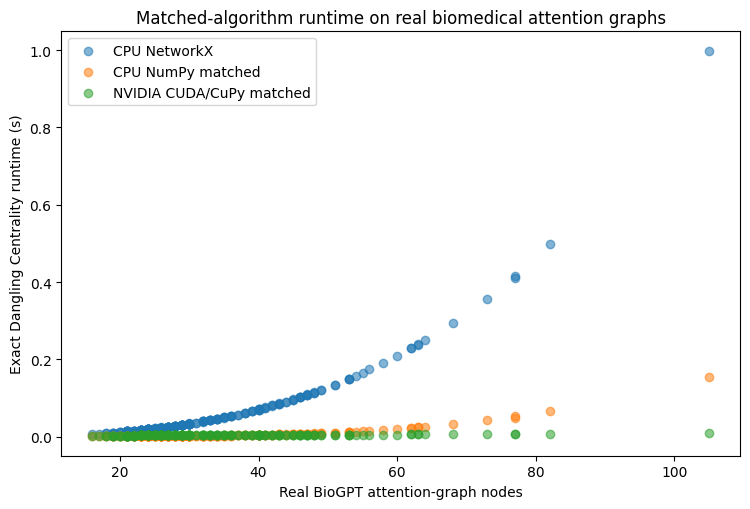

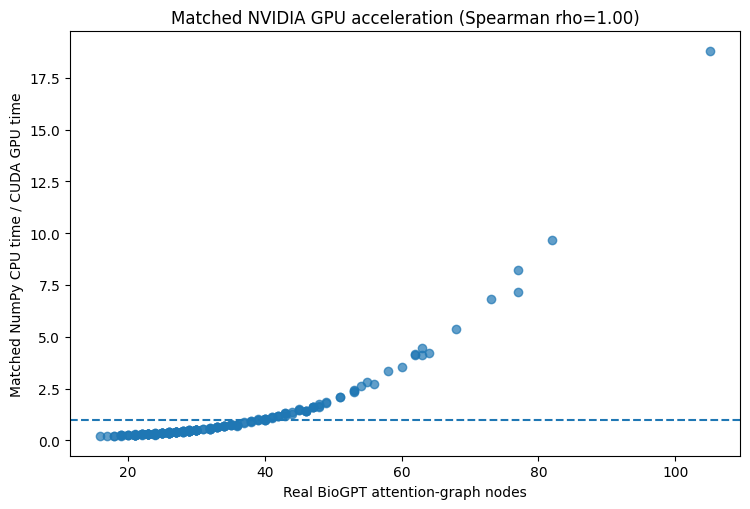

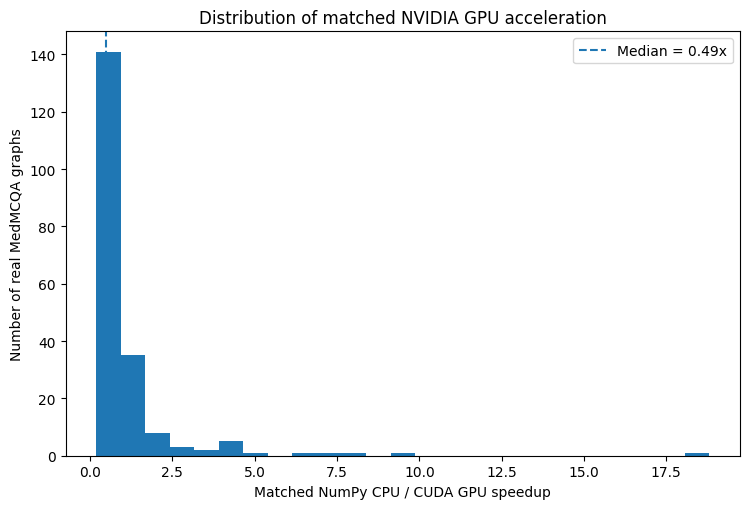

Saved: /content/gtc_2027_matched_numpy_cuda/matched_runtime_three_backends.png
Saved: /content/gtc_2027_matched_numpy_cuda/matched_speedup_vs_nodes.png
Saved: /content/gtc_2027_matched_numpy_cuda/matched_speedup_distribution.png


In [16]:
# Figure 1: three-backend runtime vs graph size.
plt.figure(figsize=(7.6, 5.2))
plt.scatter(analysis["n_nodes"], analysis["networkx_seconds"], alpha=0.55, label="CPU NetworkX")
plt.scatter(analysis["n_nodes"], analysis["numpy_matched_seconds"], alpha=0.55, label="CPU NumPy matched")
plt.scatter(analysis["n_nodes"], analysis["cuda_matched_seconds"], alpha=0.55, label="NVIDIA CUDA/CuPy matched")
plt.xlabel("Real BioGPT attention-graph nodes")
plt.ylabel("Exact Dangling Centrality runtime (s)")
plt.title("Matched-algorithm runtime on real biomedical attention graphs")
plt.legend()
plt.tight_layout()
fig1 = OUTPUT_DIR / "matched_runtime_three_backends.png"
plt.savefig(fig1, dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: primary matched speedup vs graph size.
plt.figure(figsize=(7.6, 5.2))
plt.scatter(analysis["n_nodes"], analysis["speedup_numpy_over_cuda"], alpha=0.70)
plt.axhline(1.0, linestyle="--")
plt.xlabel("Real BioGPT attention-graph nodes")
plt.ylabel("Matched NumPy CPU time / CUDA GPU time")
plt.title(f"Matched NVIDIA GPU acceleration (Spearman rho={rho_nodes:.2f})")
plt.tight_layout()
fig2 = OUTPUT_DIR / "matched_speedup_vs_nodes.png"
plt.savefig(fig2, dpi=300, bbox_inches="tight")
plt.show()

# Figure 3: primary matched speedup distribution.
plt.figure(figsize=(7.6, 5.2))
plt.hist(analysis["speedup_numpy_over_cuda"], bins=25)
plt.axvline(matched_median, linestyle="--", label=f"Median = {matched_median:.2f}x")
plt.xlabel("Matched NumPy CPU / CUDA GPU speedup")
plt.ylabel("Number of real MedMCQA graphs")
plt.title("Distribution of matched NVIDIA GPU acceleration")
plt.legend()
plt.tight_layout()
fig3 = OUTPUT_DIR / "matched_speedup_distribution.png"
plt.savefig(fig3, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig1)
print("Saved:", fig2)
print("Saved:", fig3)


## 16. Save evidence bundle and abstract-ready text


In [17]:
analysis.to_csv(OUTPUT_DIR / "matched_200_valid_benchmark.csv", index=False)
summary.to_csv(OUTPUT_DIR / "matched_200_statistical_summary.csv", index=False)
size_summary.to_csv(OUTPUT_DIR / "matched_200_size_strata.csv", index=False)

metadata = {
    "model": MODEL_NAME,
    "dataset": DATASET_NAME,
    "dataset_split": DATASET_SPLIT,
    "n_requested": int(N),
    "n_valid": int(n_valid),
    "timing_repeats": int(MATCHED_REPEATS),
    "bootstrap_draws": int(BOOTSTRAP_DRAWS),
    "agreement_atol": float(AGREEMENT_ATOL),
    "python": platform.python_version(),
    "pytorch": torch.__version__,
    "numpy": np.__version__,
    "cupy": cp.__version__,
    "networkx": nx.__version__,
    "cuda_runtime": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0),
    "gpu_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2),
    "cpu": cpu_model_name(),
    "logical_cpu_cores": os.cpu_count(),
    "primary_endpoint": "median matched NumPy CPU / CUDA-CuPy GPU exact Dangling Centrality runtime ratio",
    "gpu_timing_includes": "graph-to-adjacency conversion, CPU-to-GPU transfer, CUDA computation, GPU-to-CPU result transfer",
}
with open(OUTPUT_DIR / "matched_environment_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

abstract_txt = OUTPUT_DIR / "GTC_ABSTRACT_EVIDENCE.txt"
with open(abstract_txt, "w") as f:
    f.write("NVIDIA GTC 2027 — matched-algorithm benchmark evidence\n")
    f.write("=" * 70 + "\n")
    f.write(f"Valid real BioGPT/MedMCQA graphs: {n_valid}/{N}\n")
    f.write(
        f"PRIMARY matched NumPy-CPU/CUDA-GPU median speedup: {matched_median:.3f}x "
        f"(bootstrap 95% CI {matched_ci[0]:.3f}–{matched_ci[1]:.3f}x)\n"
    )
    f.write(
        f"Matched geometric mean speedup: {matched_geom:.3f}x "
        f"(bootstrap 95% CI {matched_geom_ci[0]:.3f}–{matched_geom_ci[1]:.3f}x)\n"
    )
    f.write(f"GPU faster than matched NumPy on: {pct_gpu_faster:.2f}% of graphs\n")
    f.write(f"At least 2x / 5x / 10x faster: {pct_2x:.2f}% / {pct_5x:.2f}% / {pct_10x:.2f}%\n")
    f.write(f"Wilcoxon NumPy > CUDA: statistic={wilcox_matched.statistic:.4f}, p={wilcox_matched.pvalue:.6e}\n")
    f.write(f"Nodes vs matched speedup: rho={rho_nodes:.4f}, p={p_nodes:.6e}\n")
    f.write(f"Matched NumPy throughput: {a_np_qps:.3f} graphs/s\n")
    f.write(f"CUDA throughput: {gpu_qps:.3f} graphs/s\n")
    f.write(f"Fair end-to-end pipeline speedup: {pipeline_speedup:.3f}x\n")
    f.write(f"Fair end-to-end time reduction: {pipeline_reduction:.2f}%\n")
    f.write(f"Maximum numerical discrepancy: {max_err:.6e}\n")
    f.write("\nSECONDARY CONTEXT ONLY\n")
    f.write(f"Original NetworkX/CUDA median speedup: {legacy_median:.3f}x\n")
    f.write(f"Original NetworkX/matched NumPy median speedup: {cpu_algo_median:.3f}x\n")
    f.write("\nABSTRACT SENTENCE TEMPLATE\n")
    f.write(
        "Across {n} real BioGPT attention graphs from MedMCQA, the NVIDIA CUDA/CuPy backend "
        "computed the exact Dangling Centrality with a median {s:.2f}x speedup over a matched "
        "NumPy CPU implementation (95% bootstrap CI {lo:.2f}–{hi:.2f}x), while preserving "
        "numerical agreement (maximum absolute discrepancy {err:.2e}). The accelerated graph "
        "backend reduced the fixed-GPU-inference end-to-end auditing time by {red:.1f}%.\n".format(
            n=n_valid, s=matched_median, lo=matched_ci[0], hi=matched_ci[1], err=max_err, red=pipeline_reduction
        )
    )

zip_path = shutil.make_archive(
    "/content/NVIDIA_GTC_2027_Matched_NumPy_CUDA_Evidence",
    "zip",
    root_dir=str(OUTPUT_DIR)
)

print("Abstract evidence:", abstract_txt)
print("Evidence ZIP:", zip_path)
print("\n--- ABSTRACT SENTENCE ---")
print(open(abstract_txt).read().split("ABSTRACT SENTENCE TEMPLATE\n", 1)[1])


Abstract evidence: /content/gtc_2027_matched_numpy_cuda/GTC_ABSTRACT_EVIDENCE.txt
Evidence ZIP: /content/NVIDIA_GTC_2027_Matched_NumPy_CUDA_Evidence.zip

--- ABSTRACT SENTENCE ---
Across 200 real BioGPT attention graphs from MedMCQA, the NVIDIA CUDA/CuPy backend computed the exact Dangling Centrality with a median 0.49x speedup over a matched NumPy CPU implementation (95% bootstrap CI 0.44–0.55x), while preserving numerical agreement (maximum absolute discrepancy 2.74e-06). The accelerated graph backend reduced the fixed-GPU-inference end-to-end auditing time by 3.1%.



## 17. Interpretation gate before abstract submission

Use the following decision rule after the run:

- **If the matched NumPy/CUDA median speedup 95% CI is entirely above 1×:** the NVIDIA acceleration claim is supported even after controlling for algorithmic/vectorization differences.
- **If the matched median is near 1× or its CI crosses 1×:** do not headline GPU speedup; the earlier NetworkX/GPU gain was partly an implementation/algorithmic effect.
- **If CUDA is slower on small graphs but faster on larger graphs:** report the crossover/scaling result and avoid claiming uniform acceleration.
- Always report the matched result as the primary benchmark. Keep NetworkX/CUDA as historical context only.

Once this cell's criteria are satisfied, the generated `GTC_ABSTRACT_EVIDENCE.txt` contains the numbers we should use to draft the NVIDIA GTC 2027 abstract.
